In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/cardekho.csv')

# Basic info and first few rows
print("Dataset Information:")
display(df.info())
print("\nFirst 5 rows of the dataset:")
display(df.head())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


None


First 5 rows of the dataset:


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [16]:
import pandas as pd

# Using astype(str) to ensure .str accessor works even if cell is re-run
df['max_power'] = pd.to_numeric(df['max_power'].astype(str).str.split(' ').str[0], errors='coerce')


df['mileage(km/ltr/kg)'] = df['mileage(km/ltr/kg)'].fillna(df['mileage(km/ltr/kg)'].median())
df['engine'] = df['engine'].fillna(df['engine'].median())
df['max_power'] = df['max_power'].fillna(df['max_power'].median())
df['seats'] = df['seats'].fillna(df['seats'].mode()[0])

# Feature Selection: Removing 'name' for now as it has too many unique values
df_model = df.drop(['name'], axis=1)

# One-Hot Encoding for categorical features
df_model = pd.get_dummies(df_model, drop_first=True)

print("Preprocessed Data Shape:", df_model.shape)
display(df_model.head())

Preprocessed Data Shape: (8128, 17)


,year,selling_price,km_driven,mileage(km/ltr/kg),engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,2014,450000,145500,23.40,1248.0,74.00,5.0,True,False,False,True,False,True,False,False,False,False
1,2014,370000,120000,21.14,1498.0,103.52,5.0,True,False,False,True,False,True,False,True,False,False
2,2006,158000,140000,17.70,1497.0,78.00,5.0,False,False,True,True,False,True,False,False,False,True
3,2010,225000,127000,23.00,1396.0,90.00,5.0,True,False,False,True,False,True,False,False,False,False
4,2007,130000,120000,16.10,1298.0,88.20,5.0,False,False,True,True,False,True,False,False,False,False


In [17]:
from sklearn.model_selection import train_test_split

# Splitting the data into Features (X) and Target (y)
X = df_model.drop('selling_price', axis=1)
y = df_model['selling_price']

# Performing Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (6502, 16)
Testing set size: (1626, 16)


In [18]:
from google.colab import files

# Saving the preprocessed dataframe to CSV
df_model.to_csv('car_preprocessed_data.csv', index=False)

# Downloading the file
files.download('car_preprocessed_data.csv')
print('CSV file ready for download!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

CSV file ready for download!


In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Initializing the model
lr_model = LinearRegression()

# Training the model
lr_model.fit(X_train, y_train)

# Making predictions
y_pred_test = lr_model.predict(X_test)

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

# Adjusted R2 Calculation
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"--- Linear Regression Metrics ---")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"Adjusted R2 Score: {adj_r2:.4f}")

--- Linear Regression Metrics ---
MAE: 268886.60
MSE: 198038765899.45
RMSE: 445015.47
R2 Score: 0.6979
Adjusted R2 Score: 0.6949


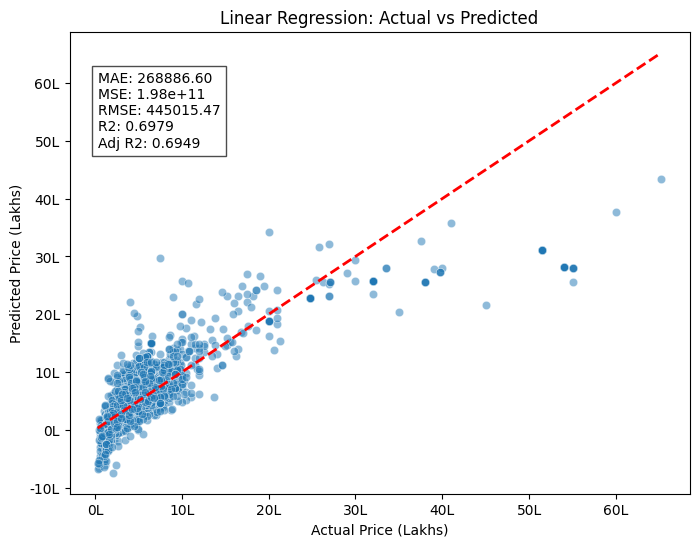

In [20]:
import matplotlib.ticker as ticker

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/100000)}L'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'{int(y/100000)}L'))

stats_text = f'MAE: {mae:.2f}\nMSE: {mse:.2e}\nRMSE: {rmse:.2f}\nR2: {r2:.4f}\nAdj R2: {adj_r2:.4f}'
plt.text(x=y_test.min(), y=y_test.max()*0.75, s=stats_text, fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.show()

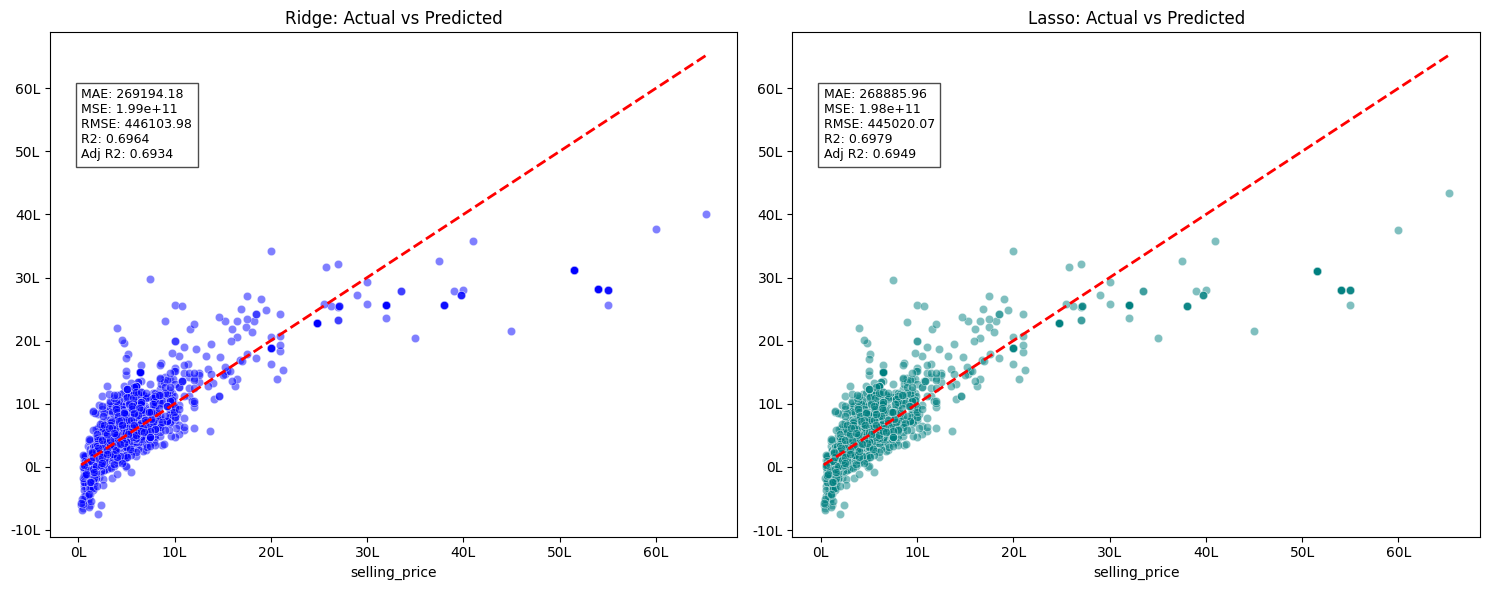

In [21]:
from sklearn.linear_model import Ridge, Lasso

# Ridge
ridge = Ridge(alpha=1.0).fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mae_r, mse_r, rmse_r, r2_r = mean_absolute_error(y_test, y_pred_ridge), mean_squared_error(y_test, y_pred_ridge), np.sqrt(mean_squared_error(y_test, y_pred_ridge)), r2_score(y_test, y_pred_ridge)
adj_r2_r = 1 - (1 - r2_r) * (n - 1) / (n - p - 1)

# Lasso
lasso = Lasso(alpha=1.0).fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
mae_l, mse_l, rmse_l, r2_l = mean_absolute_error(y_test, y_pred_lasso), mean_squared_error(y_test, y_pred_lasso), np.sqrt(mean_squared_error(y_test, y_pred_lasso)), r2_score(y_test, y_pred_lasso)
adj_r2_l = 1 - (1 - r2_l) * (n - 1) / (n - p - 1)

plt.figure(figsize=(15, 6))
for i, (name, y_p, m, ms, rm, r, ar, col) in enumerate([('Ridge', y_pred_ridge, mae_r, mse_r, rmse_r, r2_r, adj_r2_r, 'blue'), ('Lasso', y_pred_lasso, mae_l, mse_l, rmse_l, r2_l, adj_r2_l, 'teal')], 1):
    plt.subplot(1, 2, i)
    sns.scatterplot(x=y_test, y=y_p, color=col, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/100000)}L'))
    plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'{int(y/100000)}L'))
    txt = f'MAE: {m:.2f}\nMSE: {ms:.2e}\nRMSE: {rm:.2f}\nR2: {r:.4f}\nAdj R2: {ar:.4f}'
    plt.text(x=y_test.min(), y=y_test.max()*0.75, s=txt, fontsize=9, bbox=dict(facecolor='white', alpha=0.7))
    plt.title(f'{name}: Actual vs Predicted')
plt.tight_layout()
plt.show()

In [22]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# SVR requires scaled features for optimal performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training SVR with RBF kernel
svr_model = SVR(kernel='rbf', C=1000000, epsilon=0.1)
svr_model.fit(X_train_scaled, y_train)
y_pred_svr = svr_model.predict(X_test_scaled)

# Evaluation Metrics
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test, y_pred_svr)

# Adjusted R2 Calculation
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2_svr = 1 - (1 - r2_svr) * (n - 1) / (n - p - 1)

print(f'--- SVR Metrics ---')
print(f'MAE: {mae_svr:.2f}')
print(f'MSE: {mse_svr:.2f}')
print(f'RMSE: {rmse_svr:.2f}')
print(f'R2 Score: {r2_svr:.4f}')
print(f'Adjusted R2 Score: {adj_r2_svr:.4f}')

--- SVR Metrics ---
MAE: 98895.19
MSE: 46929299226.30
RMSE: 216631.71
R2 Score: 0.9284
Adjusted R2 Score: 0.9277


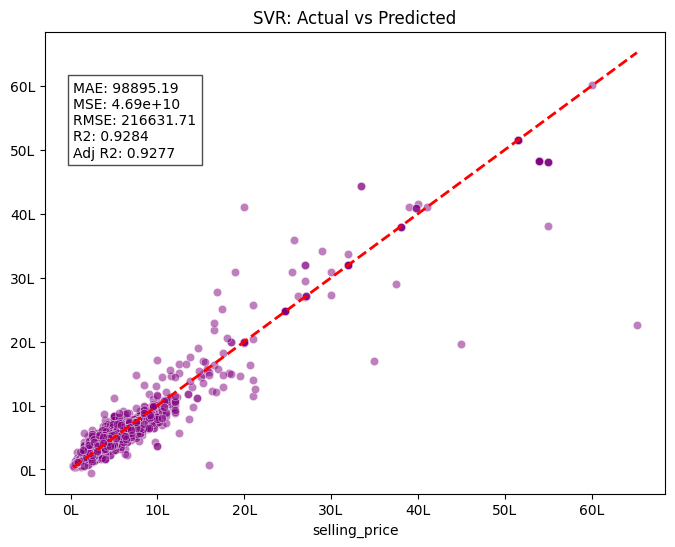

In [23]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_svr, color='purple', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/100000)}L'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'{int(y/100000)}L'))

stats_text = f'MAE: {mae_svr:.2f}\nMSE: {mse_svr:.2e}\nRMSE: {rmse_svr:.2f}\nR2: {r2_svr:.4f}\nAdj R2: {adj_r2_svr:.4f}'
plt.text(x=y_test.min(), y=y_test.max()*0.75, s=stats_text, fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

plt.title('SVR: Actual vs Predicted')
plt.show()

In [24]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

# KNN works better with scaled data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initializing KNN
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

# Evaluation Metrics
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test, y_pred_knn)
adj_r2_knn = 1 - (1 - r2_knn) * (n - 1) / (n - p - 1)

print(f'--- KNN Metrics ---\nMAE: {mae_knn:.2f}\nMSE: {mse_knn:.2f}\nRMSE: {rmse_knn:.2f}\nR2 Score: {r2_knn:.4f}\nAdjusted R2 Score: {adj_r2_knn:.4f}')

--- KNN Metrics ---
MAE: 96817.49
MSE: 35753473275.95
RMSE: 189085.89
R2 Score: 0.9455
Adjusted R2 Score: 0.9449


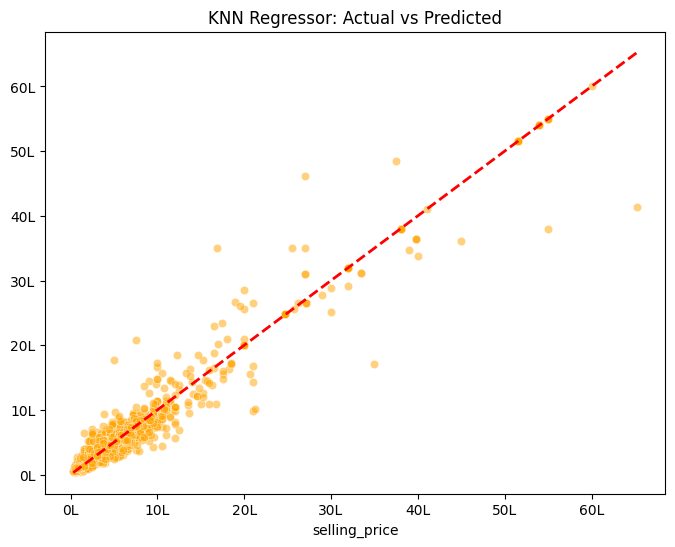

In [25]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_knn, color='orange', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/100000)}L'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'{int(y/100000)}L'))

plt.title('KNN Regressor: Actual vs Predicted')
plt.show()

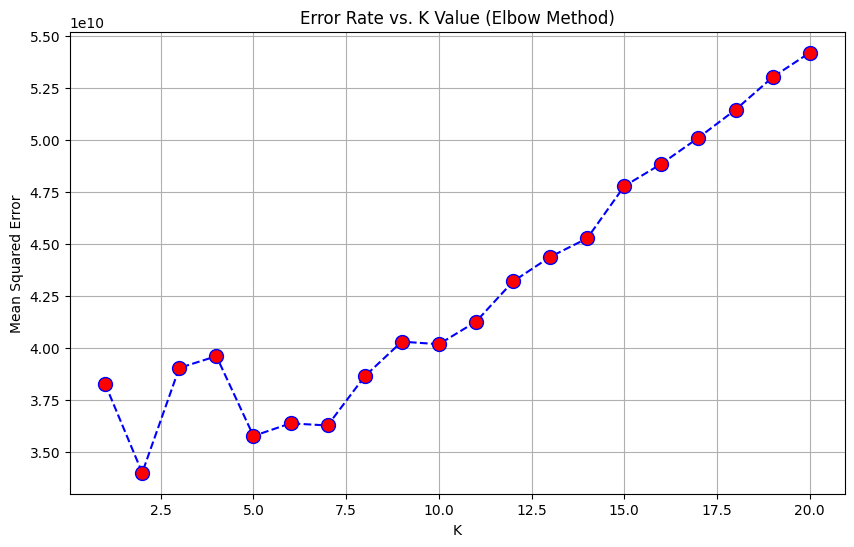

In [26]:
error_rate = []
k_range = range(1, 21)

for i in k_range:
    knn = KNeighborsRegressor(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    pred_i = knn.predict(X_test_scaled)
    error_rate.append(mean_squared_error(y_test, pred_i))

plt.figure(figsize=(10,6))
plt.plot(k_range, error_rate, color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value (Elbow Method)')
plt.xlabel('K')
plt.ylabel('Mean Squared Error')
plt.grid(True)
plt.show()

In [27]:
from sklearn.tree import DecisionTreeRegressor

# Initializing the Decision Tree model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Evaluation Metrics
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)
adj_r2_dt_base = 1 - (1 - r2_dt) * (n - 1) / (n - p - 1)

print(f'--- Decision Tree Metrics ---\nMAE: {mae_dt:.2f}\nMSE: {mse_dt:.2f}\nRMSE: {rmse_dt:.2f}\nR2 Score: {r2_dt:.4f}\nAdjusted R2 Score: {adj_r2_dt_base:.4f}')

--- Decision Tree Metrics ---
MAE: 82176.59
MSE: 28444464006.57
RMSE: 168654.87
R2 Score: 0.9566
Adjusted R2 Score: 0.9562


Decision Tree - Training R2 Score: 0.9996
Decision Tree - Testing R2 Score: 0.9566


/tmp/ipykernel_8802/754567050.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=scores, palette='magma')


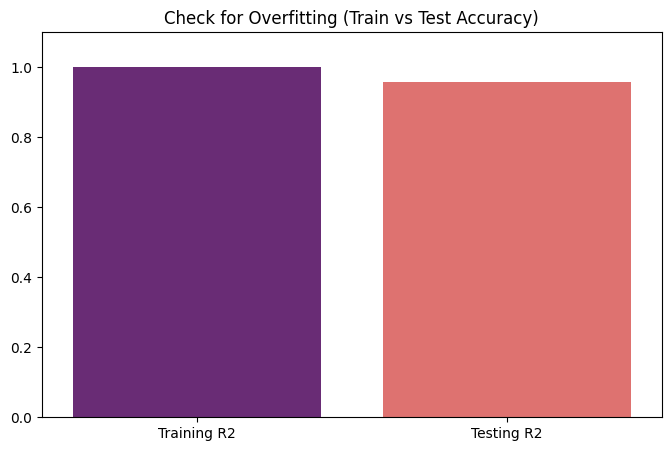

In [28]:
y_pred_train_dt = dt_model.predict(X_train)
r2_train_dt = r2_score(y_train, y_pred_train_dt)

print(f'Decision Tree - Training R2 Score: {r2_train_dt:.4f}')
print(f'Decision Tree - Testing R2 Score: {r2_dt:.4f}')

plt.figure(figsize=(8,5))
labels = ['Training R2', 'Testing R2']
scores = [r2_train_dt, r2_dt]
sns.barplot(x=labels, y=scores, palette='magma')
plt.ylim(0, 1.1)
plt.title('Check for Overfitting (Train vs Test Accuracy)')
plt.show()

In [29]:
dt_tuned = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_tuned.fit(X_train, y_train)
y_pred_dt_tuned = dt_tuned.predict(X_test)

mae_dt_tuned = mean_absolute_error(y_test, y_pred_dt_tuned)
mse_dt_tuned = mean_squared_error(y_test, y_pred_dt_tuned)
rmse_dt_tuned = np.sqrt(mse_dt_tuned)
test_score = r2_score(y_test, y_pred_dt_tuned)
adj_r2_dt = 1 - (1 - test_score) * (n - 1) / (n - p - 1)

print(f'--- Tuned Decision Tree Metrics ---\nMAE: {mae_dt_tuned:.2f}\nMSE: {mse_dt_tuned:.2f}\nRMSE: {rmse_dt_tuned:.2f}\nR2 Score: {test_score:.4f}\nAdjusted R2 Score: {adj_r2_dt:.4f}')

--- Tuned Decision Tree Metrics ---
MAE: 84324.58
MSE: 25901631951.10
RMSE: 160939.84
R2 Score: 0.9605
Adjusted R2 Score: 0.9601


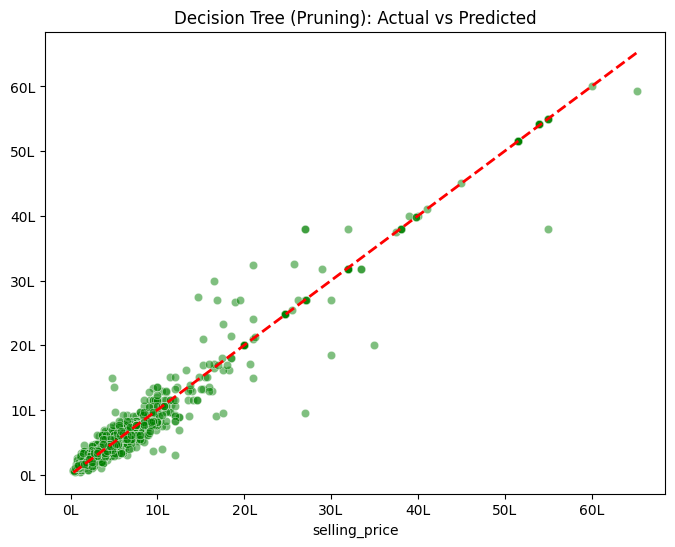

In [30]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_dt_tuned, color='green', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/100000)}L'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'{int(y/100000)}L'))

plt.title('Decision Tree (Pruning): Actual vs Predicted')
plt.show()

In [31]:
from sklearn.ensemble import RandomForestRegressor

# Initializing and Training Random Forest
rf_model = RandomForestRegressor(n_estimators=50, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Evaluation Metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)
adj_r2_rf = 1 - (1 - r2_rf) * (n - 1) / (n - p - 1)

print(f'--- Random Forest Metrics ---\nMAE: {mae_rf:.2f}\nMSE: {mse_rf:.2f}\nRMSE: {rmse_rf:.2f}\nR2 Score: {r2_rf:.4f}\nAdjusted R2 Score: {adj_r2_rf:.4f}')

--- Random Forest Metrics ---
MAE: 70457.03
MSE: 20596698811.22
RMSE: 143515.50
R2 Score: 0.9686
Adjusted R2 Score: 0.9683


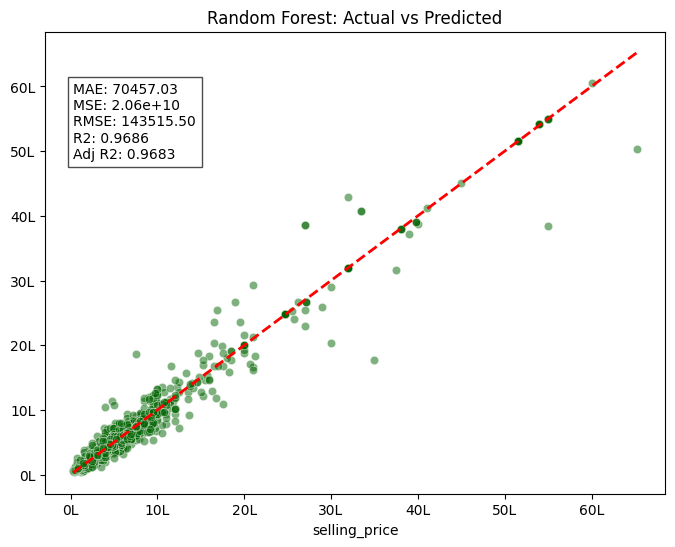

In [32]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_rf, color='darkgreen', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/100000)}L'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'{int(y/100000)}L'))

stats_text = f'MAE: {mae_rf:.2f}\nMSE: {mse_rf:.2e}\nRMSE: {rmse_rf:.2f}\nR2: {r2_rf:.4f}\nAdj R2: {adj_r2_rf:.4f}'
plt.text(x=y_test.min(), y=y_test.max()*0.75, s=stats_text, fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

plt.title('Random Forest: Actual vs Predicted')
plt.show()

In [34]:
from sklearn.ensemble import AdaBoostRegressor

ada_model = AdaBoostRegressor(n_estimators=100, random_state=42)
ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)

# Evaluation Metrics
mae_ada = mean_absolute_error(y_test, y_pred_ada)
mse_ada = mean_squared_error(y_test, y_pred_ada)
rmse_ada = np.sqrt(mse_ada)
r2_ada = r2_score(y_test, y_pred_ada)

# Adjusted R2 Calculation
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2_ada = 1 - (1 - r2_ada) * (n - 1) / (n - p - 1)

print(f"--- AdaBoost Metrics ---")
print(f"MAE: {mae_ada:.2f}")
print(f"MSE: {mse_ada:.2f}")
print(f"RMSE: {rmse_ada:.2f}")
print(f"R2 Score: {r2_ada:.4f}")
print(f"Adjusted R2 Score: {adj_r2_ada:.4f}")

--- AdaBoost Metrics ---
MAE: 470719.82
MSE: 252365042065.09
RMSE: 502359.47
R2 Score: 0.6150
Adjusted R2 Score: 0.6112


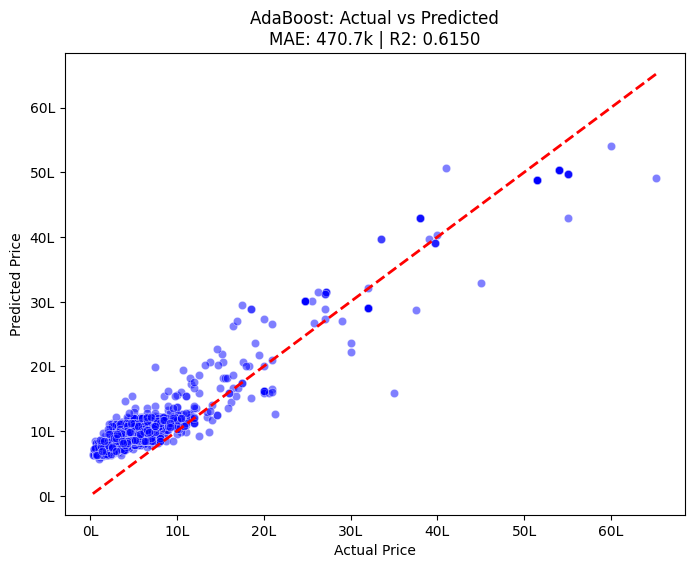

In [35]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_ada, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/100000)}L'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'{int(y/100000)}L'))

plt.title(f'AdaBoost: Actual vs Predicted\nMAE: {mae_ada/1000:.1f}k | R2: {r2_ada:.4f}')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

In [36]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

# Evaluation Metrics
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

# Adjusted R2 Calculation
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2_gb = 1 - (1 - r2_gb) * (n - 1) / (n - p - 1)

print(f"--- Gradient Boosting Metrics ---")
print(f"MAE: {mae_gb:.2f}")
print(f"MSE: {mse_gb:.2f}")
print(f"RMSE: {rmse_gb:.2f}")
print(f"R2 Score: {r2_gb:.4f}")
print(f"Adjusted R2 Score: {adj_r2_gb:.4f}")

--- Gradient Boosting Metrics ---
MAE: 92388.29
MSE: 25324213759.93
RMSE: 159135.83
R2 Score: 0.9614
Adjusted R2 Score: 0.9610


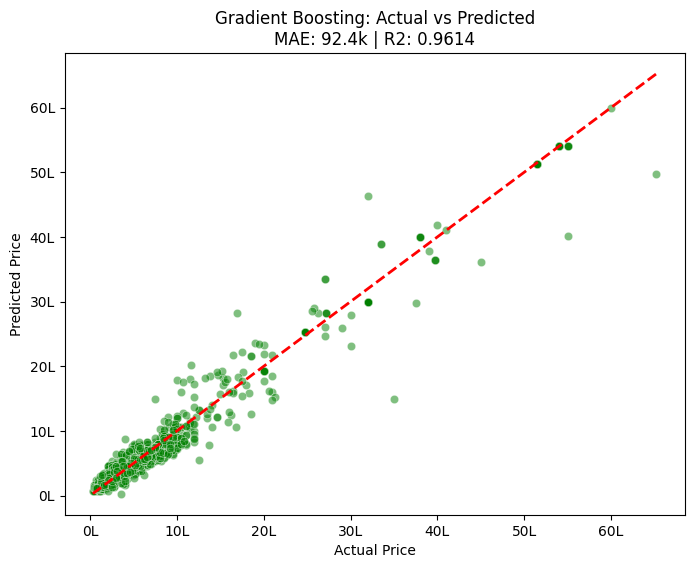

In [37]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_gb, color='green', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/100000)}L'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'{int(y/100000)}L'))

plt.title(f'Gradient Boosting: Actual vs Predicted\nMAE: {mae_gb/1000:.1f}k | R2: {r2_gb:.4f}')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

In [38]:
import xgboost as xg

xgb_model = xg.XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation Metrics
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

# Adjusted R2 Calculation
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2_xgb = 1 - (1 - r2_xgb) * (n - 1) / (n - p - 1)

print(f"--- XGBoost Metrics ---")
print(f"MAE: {mae_xgb:.2f}")
print(f"MSE: {mse_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"R2 Score: {r2_xgb:.4f}")
print(f"Adjusted R2 Score: {adj_r2_xgb:.4f}")

--- XGBoost Metrics ---
MAE: 71378.21
MSE: 25911513088.00
RMSE: 160970.53
R2 Score: 0.9605
Adjusted R2 Score: 0.9601


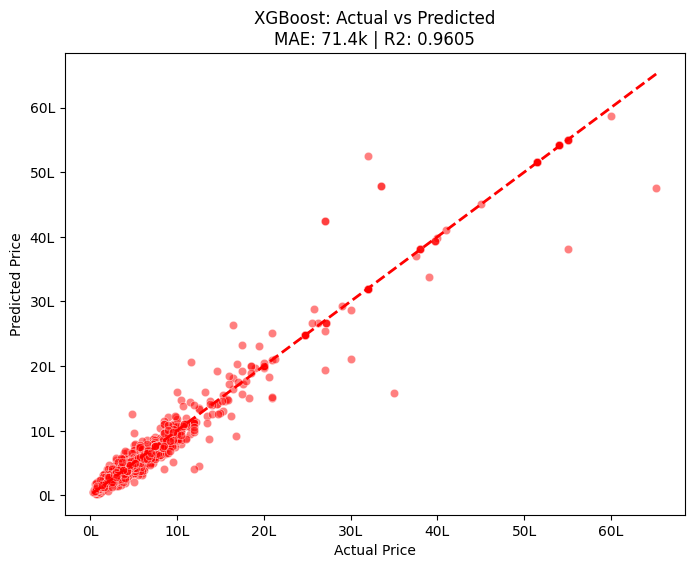

In [39]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_xgb, color='red', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/100000)}L'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'{int(y/100000)}L'))

plt.title(f'XGBoost: Actual vs Predicted\nMAE: {mae_xgb/1000:.1f}k | R2: {r2_xgb:.4f}')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

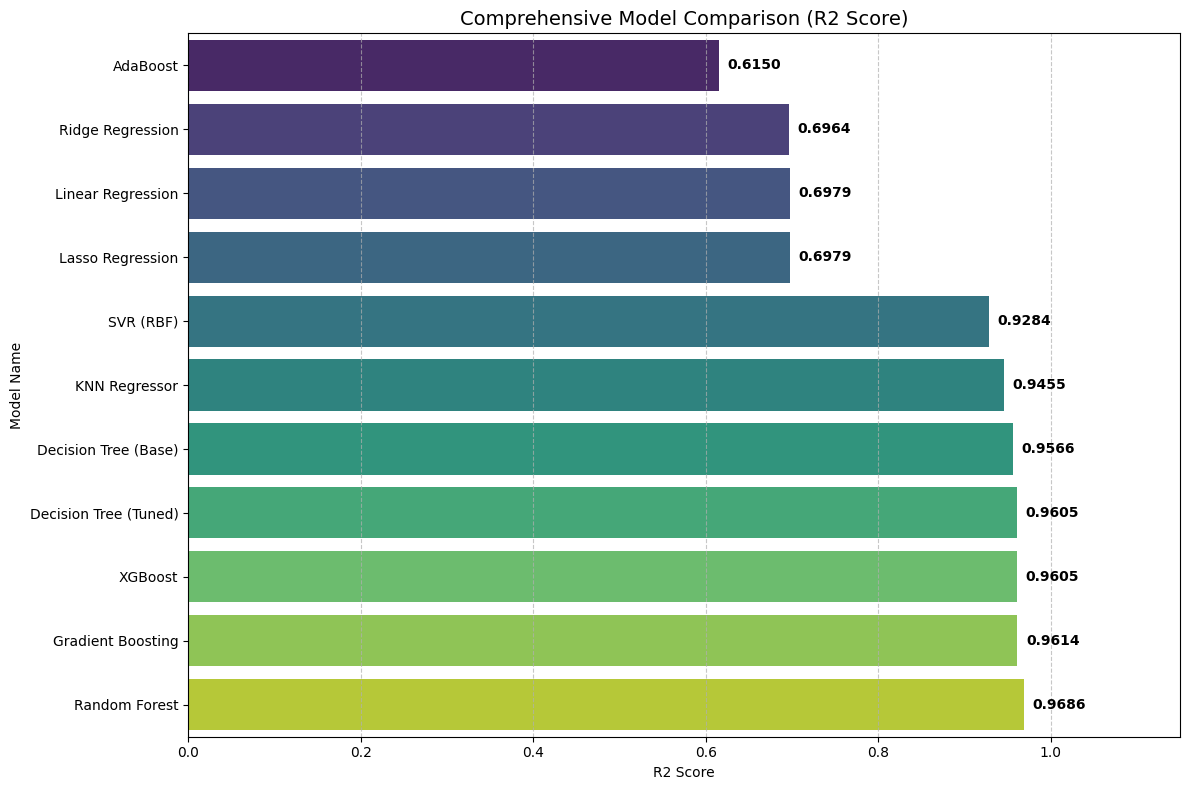

In [41]:
plt.figure(figsize=(12, 8))

# Sorting data for the plot
plot_df = performance_df.sort_values(by='R2 Score')

sns.barplot(x='R2 Score', y='Model', data=plot_df, palette='viridis', hue='Model', legend=False)

# Adding text labels for the scores
for i, score in enumerate(plot_df['R2 Score']):
    plt.text(score + 0.01, i, f'{score:.4f}', va='center', fontweight='bold')

plt.xlim(0, 1.15)
plt.title('Comprehensive Model Comparison (R2 Score)', fontsize=14)
plt.xlabel('R2 Score')
plt.ylabel('Model Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Correlations with Selling Price:
 selling_price                   1.000000
max_power                       0.747935
engine                          0.458345
year                            0.414092
fuel_Diesel                     0.206521
owner_Test Drive Car            0.115880
seats                           0.047135
seller_type_Trustmark Dealer    0.035084
fuel_LPG                       -0.037222
owner_Fourth & Above Owner     -0.075669
owner_Third Owner              -0.118956
mileage(km/ltr/kg)             -0.125040
owner_Second Owner             -0.179881
fuel_Petrol                    -0.195975
km_driven                      -0.225534
seller_type_Individual         -0.386244
transmission_Manual            -0.588845
Name: selling_price, dtype: float64


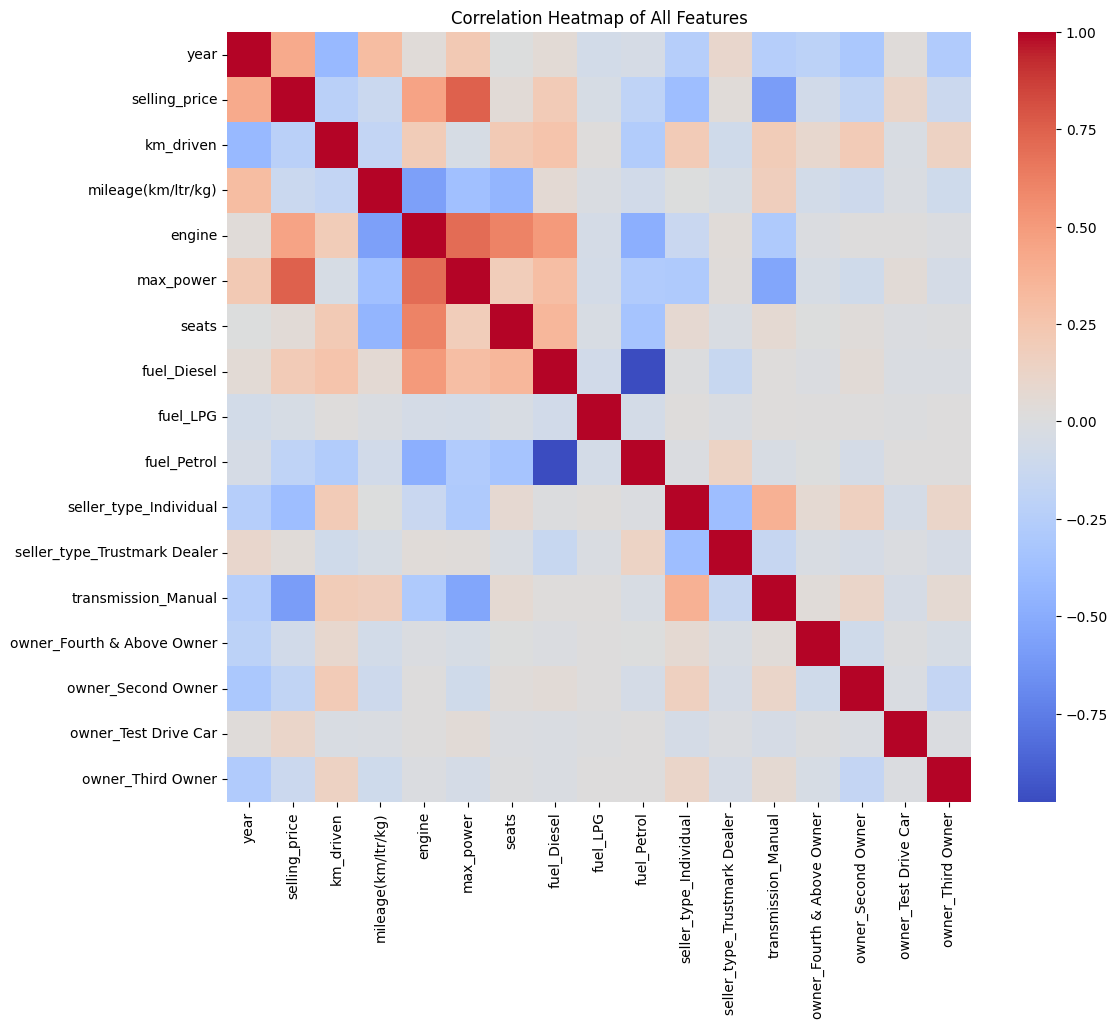

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = df_model.corr()

# Get correlations with the target variable 'selling_price'
price_correlations = correlation_matrix['selling_price'].sort_values(ascending=False)

print("Correlations with Selling Price:\n", price_correlations)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of All Features')
plt.show()

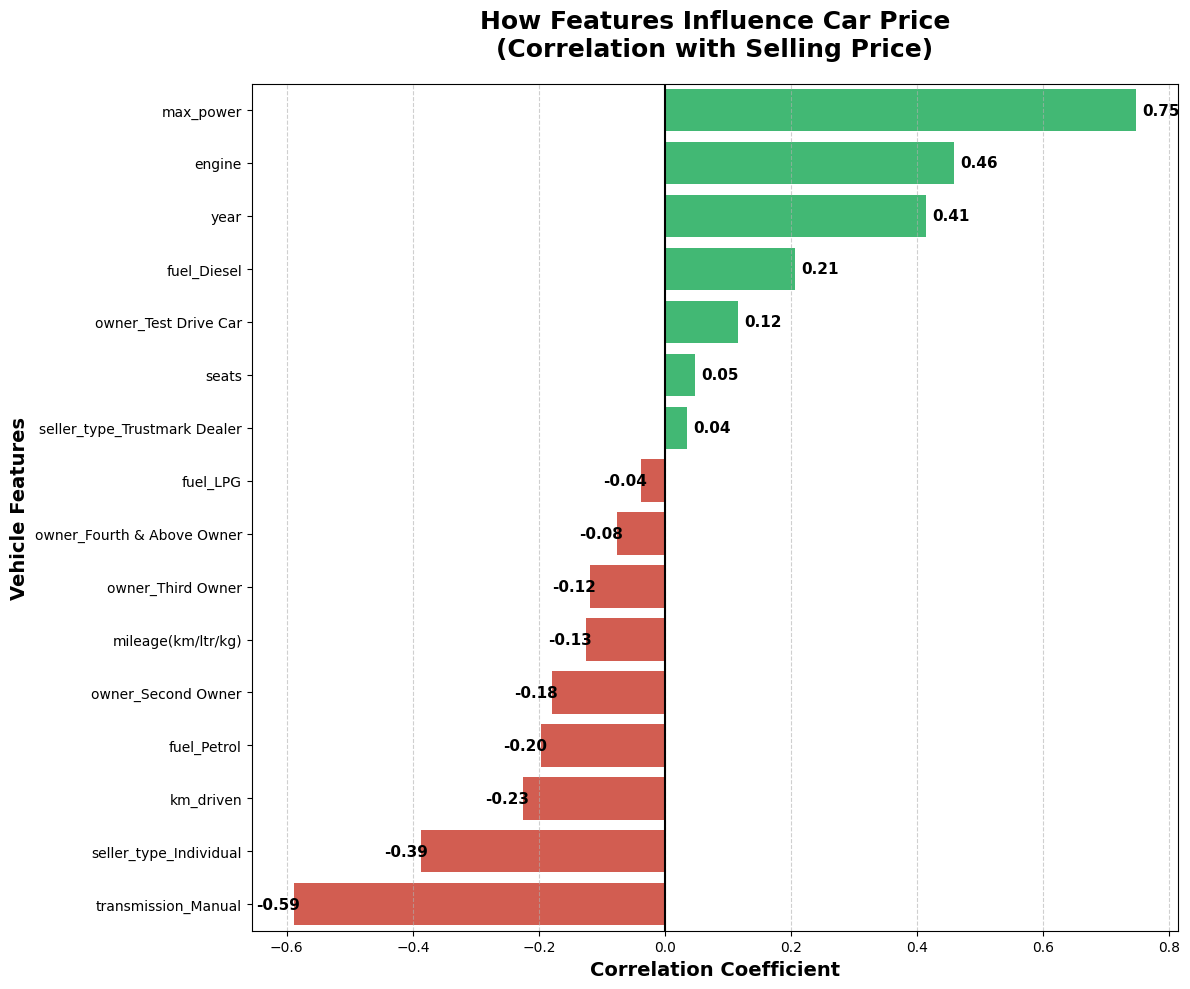

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv('/content/cardekho.csv')
df['max_power'] = pd.to_numeric(df['max_power'].astype(str).str.split(' ').str[0], errors='coerce')
df['mileage(km/ltr/kg)'] = df['mileage(km/ltr/kg)'].fillna(df['mileage(km/ltr/kg)'].median())
df['engine'] = df['engine'].fillna(df['engine'].median())
df['max_power'] = df['max_power'].fillna(df['max_power'].median())
df['seats'] = df['seats'].fillna(df['seats'].mode()[0])

df_model = df.drop(['name'], axis=1)
df_model = pd.get_dummies(df_model, drop_first=True)

# Prepare correlation data excluding the target itself
correlation_data = df_model.corr()['selling_price'].sort_values(ascending=False).drop('selling_price')

# Create the plot
plt.figure(figsize=(12, 10))

# Define colors: Green for positive, Red for negative correlation
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in correlation_data.values]

sns.barplot(x=correlation_data.values, y=correlation_data.index, palette=colors, hue=correlation_data.index, legend=False)

plt.title('How Features Influence Car Price\n(Correlation with Selling Price)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Correlation Coefficient', fontsize=14, fontweight='bold')
plt.ylabel('Vehicle Features', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
plt.grid(axis='x', linestyle='--', alpha=0.6)

for i, v in enumerate(correlation_data.values):
    plt.text(v + (0.01 if v > 0 else -0.06), i, f'{v:.2f}',
             va='center', fontsize=11, fontweight='bold',
             color='black' if abs(v) < 0.1 else 'black' if v < 0 else 'black')

plt.tight_layout()
plt.savefig('feature_correlation_poster.png', dpi=300, bbox_inches='tight')
plt.show()

In [48]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
import xgboost as xg
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Prepare Data
X = df_model.drop('selling_price', axis=1)
y = df_model['selling_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling for SVR and KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Defining evaluation function
def evaluate(model, X_t, y_t):
    preds = model.predict(X_t)
    return r2_score(y_t, preds), mean_absolute_error(y_t, preds), mean_squared_error(y_t, preds), np.sqrt(mean_squared_error(y_t, preds))

# 2. Train and Evaluate all 11 Models
lr = LinearRegression().fit(X_train, y_train)
r2, mae, mse, rmse = evaluate(lr, X_test, y_test)

ridge = Ridge().fit(X_train, y_train)
r2_r, mae_r, mse_r, rmse_r = evaluate(ridge, X_test, y_test)

lasso = Lasso().fit(X_train, y_train)
r2_l, mae_l, mse_l, rmse_l = evaluate(lasso, X_test, y_test)

svr = SVR(kernel='rbf', C=1000000).fit(X_train_scaled, y_train)
r2_svr, mae_svr, mse_svr, rmse_svr = evaluate(svr, X_test_scaled, y_test)

knn = KNeighborsRegressor(n_neighbors=5).fit(X_train_scaled, y_train)
r2_knn, mae_knn, mse_knn, rmse_knn = evaluate(knn, X_test_scaled, y_test)

dt_base = DecisionTreeRegressor(random_state=42).fit(X_train, y_train)
r2_dt, mae_dt, mse_dt, rmse_dt = evaluate(dt_base, X_test, y_test)

dt_tuned = DecisionTreeRegressor(max_depth=10, random_state=42).fit(X_train, y_train)
test_score, mae_dt_tuned, mse_dt_tuned, rmse_dt_tuned = evaluate(dt_tuned, X_test, y_test)

rf = RandomForestRegressor(n_estimators=50, random_state=42).fit(X_train, y_train)
r2_rf, mae_rf, mse_rf, rmse_rf = evaluate(rf, X_test, y_test)

ada = AdaBoostRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
r2_ada, mae_ada, mse_ada, rmse_ada = evaluate(ada, X_test, y_test)

gb = GradientBoostingRegressor(random_state=42).fit(X_train, y_train)
r2_gb, mae_gb, mse_gb, rmse_gb = evaluate(gb, X_test, y_test)

xgb = xg.XGBRegressor(random_state=42).fit(X_train, y_train)
r2_xgb, mae_xgb, mse_xgb, rmse_xgb = evaluate(xgb, X_test, y_test)

# 3. Compile Comparison Table
comparison_data = [
    ['Linear Regression', r2, mae, mse, rmse], ['Ridge Regression', r2_r, mae_r, mse_r, rmse_r], ['Lasso Regression', r2_l, mae_l, mse_l, rmse_l],
    ['SVR (RBF)', r2_svr, mae_svr, mse_svr, rmse_svr], ['KNN Regressor', r2_knn, mae_knn, mse_knn, rmse_knn],
    ['Decision Tree (Base)', r2_dt, mae_dt, mse_dt, rmse_dt], ['Decision Tree (Tuned)', test_score, mae_dt_tuned, mse_dt_tuned, rmse_dt_tuned],
    ['Random Forest', r2_rf, mae_rf, mse_rf, rmse_rf], ['AdaBoost', r2_ada, mae_ada, mse_ada, rmse_ada],
    ['Gradient Boosting', r2_gb, mae_gb, mse_gb, rmse_gb], ['XGBoost', r2_xgb, mae_xgb, mse_xgb, rmse_xgb]
]

performance_df = pd.DataFrame(comparison_data, columns=['Model', 'R2 Score', 'MAE', 'MSE', 'RMSE'])
n, p = X_test.shape[0], X_test.shape[1]
performance_df['Adjusted R2'] = 1 - (1 - performance_df['R2 Score']) * (n - 1) / (n - p - 1)
performance_df = performance_df.sort_values(by='R2 Score', ascending=False).reset_index(drop=True)
print("--- Comprehensive Model Performance Comparison ---")
display(performance_df.round(4))

--- Comprehensive Model Performance Comparison ---


,Model,R2 Score,MAE,MSE,RMSE,Adjusted R2
0,Random Forest,0.9686,70457.0274,2.059670e+10,143515.5002,0.9683
1,Gradient Boosting,0.9614,92388.2865,2.532421e+10,159135.8343,0.9610
2,Decision Tree (Tuned),0.9605,84324.5791,2.590163e+10,160939.8395,0.9601
3,XGBoost,0.9605,71378.2109,2.591151e+10,160970.5348,0.9601
4,Decision Tree (Base),0.9566,82176.5899,2.844446e+10,168654.8665,0.9562
5,KNN Regressor,0.9455,96817.4924,3.575347e+10,189085.8886,0.9449
6,SVR (RBF),0.9284,98895.1932,4.692930e+10,216631.7133,0.9277
7,Linear Regression,0.6979,268886.5952,1.980388e+11,445015.4670,0.6949
8,Lasso Regression,0.6979,268885.9557,1.980429e+11,445020.0708,0.6949
9,Ridge Regression,0.6964,269194.1774,1.990088e+11,446103.9826,0.6934


/tmp/ipykernel_8802/2316420130.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fuel', y='selling_price', data=df, ax=axes[0,1], palette='Set2')
/tmp/ipykernel_8802/2316420130.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='transmission', y='selling_price', data=df, ax=axes[1,0], palette='pastel')


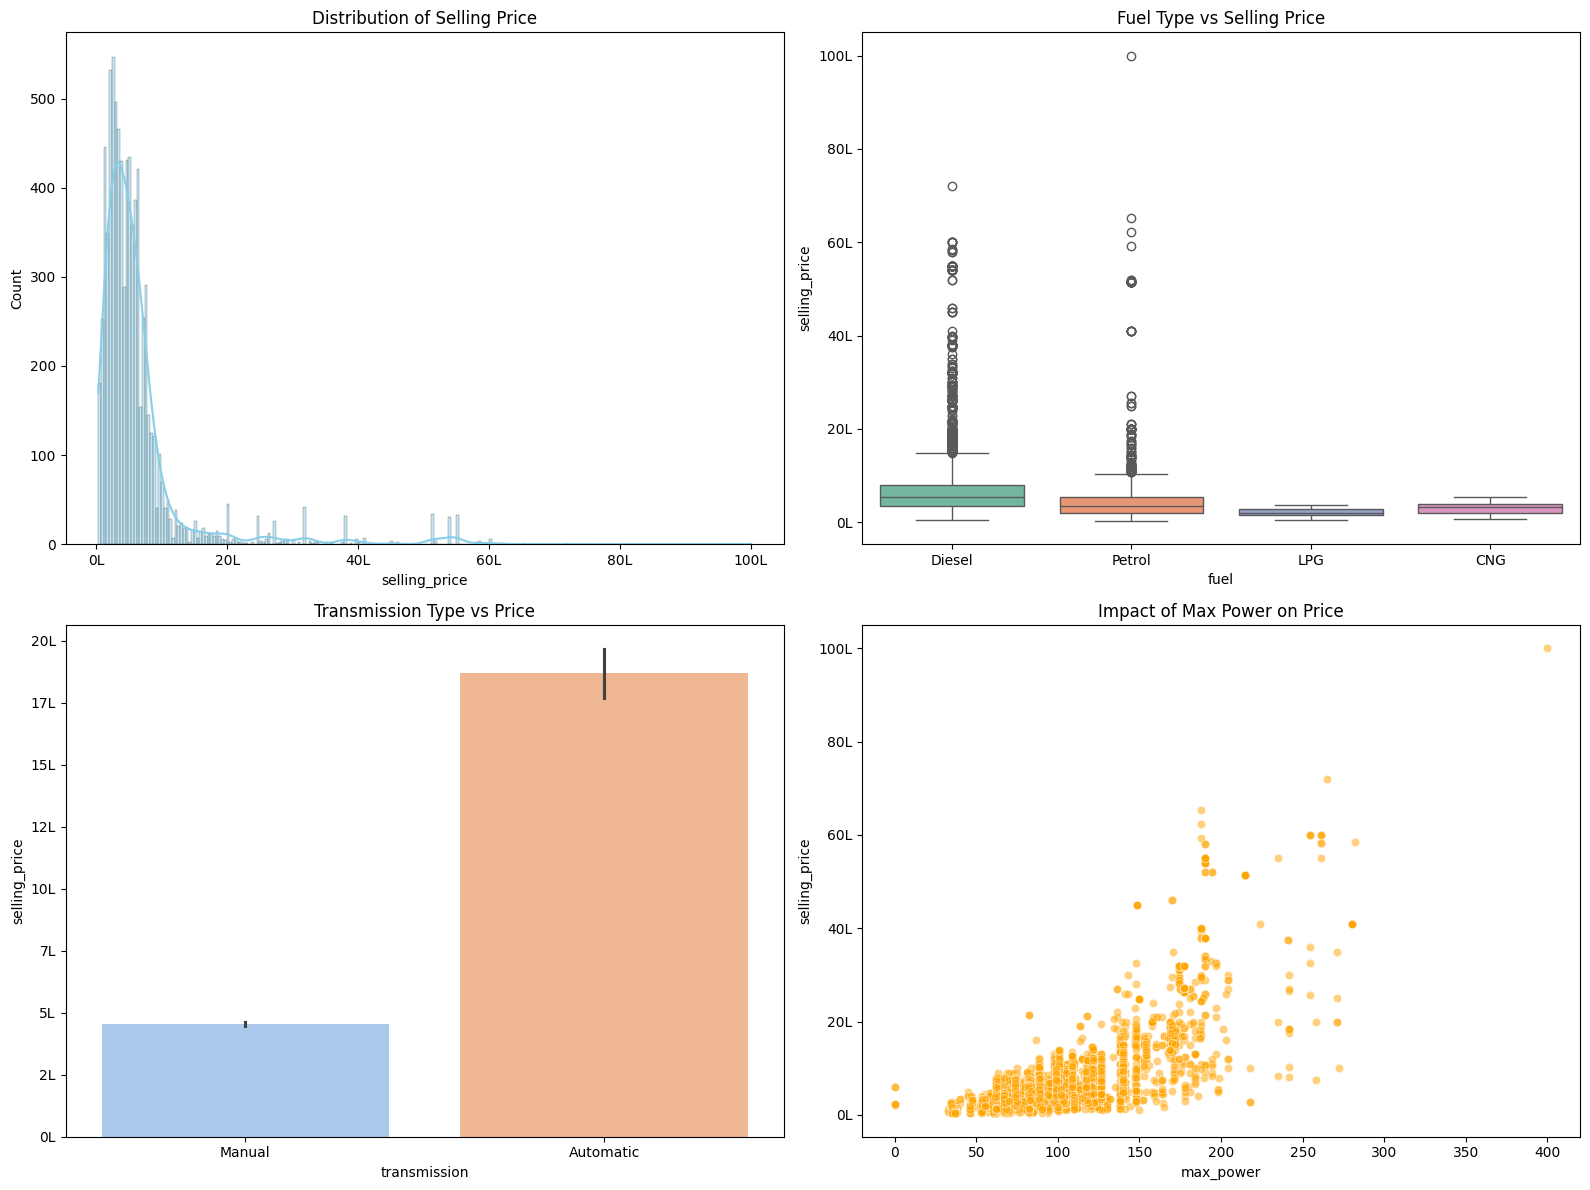

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker


fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Price Distribution
sns.histplot(df['selling_price'], kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Distribution of Selling Price')
axes[0,0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/100000)}L'))

# 2. Fuel Type vs Price
sns.boxplot(x='fuel', y='selling_price', data=df, ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Fuel Type vs Selling Price')
axes[0,1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'{int(y/100000)}L'))

# 3. Transmission vs Price
sns.barplot(x='transmission', y='selling_price', data=df, ax=axes[1,0], palette='pastel')
axes[1,0].set_title('Transmission Type vs Price')
axes[1,0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'{int(y/100000)}L'))

# 4. Max Power vs Selling Price (Scatter)
sns.scatterplot(x='max_power', y='selling_price', data=df, ax=axes[1,1], alpha=0.5, color='orange')
axes[1,1].set_title('Impact of Max Power on Price')
axes[1,1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'{int(y/100000)}L'))

plt.tight_layout()
plt.show()